# Implied Volatility Surface Engine
## SVI Calibration & Static Arbitrage Detection

**Author:** Benicio Mazzoldi
**Environment:** Google Colab

Constructs an implied volatility surface for SPY options from live market quotes,
calibrates the SVI (Stochastic Volatility Inspired) parameterization to each
expiration slice, and tests the fitted surface for static arbitrage violations.

| Stage | Method |
|---|---|
| Forward curve | Put-call parity across matched strikes |
| Implied volatility | Black-76 inversion via Brent root-finding |
| Smile calibration | Raw SVI, 5-parameter, multi-start SLSQP |
| Butterfly arbitrage | Gatheral's g(k) >= 0 condition |
| Calendar arbitrage | Total implied variance monotonic in maturity |

In [1]:
# ============================================================
# SECTION 1 | ENVIRONMENT SETUP
# ============================================================
!pip install -q yfinance

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 - registers 3d projection
from matplotlib import cm
from scipy.stats import norm
from scipy.optimize import brentq, minimize
from datetime import datetime, timezone

plt.rcParams.update({
    "figure.figsize": (11, 5.5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})
print("Environment ready.")

Environment ready.


In [2]:
# ============================================================
# SECTION 2 | CONFIGURATION
# ============================================================
UNDERLYING       = "SPY"
RF_TICKER        = "^IRX"      # 13-week T-bill yield, annualized percent

# Expiration filters
MIN_DTE          = 7           # exclude near-expiry noise / pinning
MAX_DTE          = 730         # exclude illiquid LEAPS
MAX_EXPIRIES     = 12          # slices to calibrate

# Quote quality filters
MIN_BID          = 0.05        # drop worthless / stale quotes
MAX_SPREAD_PCT   = 0.60        # drop quotes with spread > 60% of mid
MIN_OPEN_INT     = 10
MIN_PTS_PER_SLICE = 8          # slices with fewer points are not calibrated
MONEYNESS_BAND   = 0.35        # keep |log(K/F)| <= this

# SVI calibration
N_STARTS         = 12          # random restarts per slice
SEED             = 42

print(f"Target: {UNDERLYING} | DTE window: {MIN_DTE}-{MAX_DTE}d | "
      f"max slices: {MAX_EXPIRIES} | moneyness band: +/-{MONEYNESS_BAND}")

Target: SPY | DTE window: 7-730d | max slices: 12 | moneyness band: +/-0.35


In [3]:
# ============================================================
# SECTION 3 | DATA COLLECTION PIPELINE
# ============================================================
def get_spot(ticker: str) -> float:
    """Latest traded price of the underlying."""
    try:
        px = yf.Ticker(ticker).history(period="5d", auto_adjust=False)["Close"]
        if px.empty:
            raise ValueError("empty price history")
        return float(px.iloc[-1])
    except Exception as e:
        raise RuntimeError(f"Could not fetch spot for {ticker}: {e}") from e

def get_risk_free() -> float:
    """13-week T-bill yield as a flat continuously-compounded proxy."""
    try:
        y = yf.download(RF_TICKER, period="10d", progress=False, auto_adjust=True)["Close"]
        if isinstance(y, pd.DataFrame):
            y = y.iloc[:, 0]
        y = y.dropna()
        if y.empty:
            raise ValueError("empty yield series")
        return float(y.iloc[-1]) / 100.0
    except Exception:
        print("WARNING: risk-free fetch failed; defaulting to 4.0%.")
        return 0.04

def fetch_chains(ticker: str) -> pd.DataFrame:
    """Pull calls and puts for every expiry inside the DTE window.

    Returns a long DataFrame: one row per (expiry, strike, option type).
    """
    tk = yf.Ticker(ticker)
    try:
        expiries = list(tk.options)
    except Exception as e:
        raise RuntimeError(f"Could not list expirations: {e}") from e
    if not expiries:
        raise ValueError("No expirations returned by data provider.")

    today = pd.Timestamp(datetime.now(timezone.utc).date())
    rows = []
    kept = 0
    for exp in expiries:
        dte = (pd.Timestamp(exp) - today).days
        if dte < MIN_DTE or dte > MAX_DTE:
            continue
        if kept >= MAX_EXPIRIES:
            break
        try:
            ch = tk.option_chain(exp)
        except Exception as e:
            print(f"  skip {exp}: {e}")
            continue
        for df, kind in ((ch.calls, "C"), (ch.puts, "P")):
            if df is None or df.empty:
                continue
            sub = df[["strike", "bid", "ask", "lastPrice", "volume", "openInterest"]].copy()
            sub["type"] = kind
            sub["expiry"] = pd.Timestamp(exp)
            sub["dte"] = dte
            rows.append(sub)
        kept += 1

    if not rows:
        raise ValueError("No option chains passed the DTE filter.")
    out = pd.concat(rows, ignore_index=True)
    print(f"Pulled {len(out)} quotes across {out['expiry'].nunique()} expirations.")
    return out

SPOT = get_spot(UNDERLYING)
RF   = get_risk_free()
raw  = fetch_chains(UNDERLYING)

print(f"\n{UNDERLYING} spot: {SPOT:.2f} | risk-free: {RF:.2%}")
raw.head(3)

Pulled 3843 quotes across 12 expirations.

SPY spot: 739.09 | risk-free: 3.80%


,strike,bid,ask,lastPrice,volume,openInterest,type,expiry,dte
0,700.0,38.85,41.64,43.04,2.0,1.0,C,2026-08-04,7
1,701.0,37.91,40.68,43.91,1.0,1.0,C,2026-08-04,7
2,710.0,30.51,30.96,31.30,2.0,1.0,C,2026-08-04,7


In [4]:
# ============================================================
# SECTION 4 | QUOTE CLEANING
# ============================================================
def clean_quotes(df: pd.DataFrame) -> pd.DataFrame:
    """Apply liquidity and quote-integrity filters, compute mid prices."""
    d = df.copy()
    d["openInterest"] = d["openInterest"].fillna(0)
    d["volume"] = d["volume"].fillna(0)

    n0 = len(d)
    d = d[(d["bid"] > MIN_BID) & (d["ask"] > d["bid"])]
    d["mid"] = 0.5 * (d["bid"] + d["ask"])
    d["spread_pct"] = (d["ask"] - d["bid"]) / d["mid"]
    d = d[d["spread_pct"] <= MAX_SPREAD_PCT]
    d = d[d["openInterest"] >= MIN_OPEN_INT]
    d["T"] = d["dte"] / 365.25

    print(f"Quote filters: {n0} -> {len(d)} rows retained ({len(d)/n0:.0%})")
    return d.reset_index(drop=True)

quotes = clean_quotes(raw)

Quote filters: 3843 -> 2839 rows retained (74%)


In [5]:
# ============================================================
# SECTION 5 | FORWARD CURVE VIA PUT-CALL PARITY
# ============================================================
# Rather than assuming a dividend yield, back the forward out of the market:
#   C - P = exp(-rT) * (F - K)   =>   F = K + exp(rT) * (C - P)
# Estimated per expiry as the median across near-the-money matched strikes,
# which is robust to a few bad quotes.

def implied_forwards(df: pd.DataFrame, spot: float, r: float) -> pd.Series:
    fwds = {}
    for exp, grp in df.groupby("expiry"):
        c = grp[grp["type"] == "C"].set_index("strike")["mid"]
        p = grp[grp["type"] == "P"].set_index("strike")["mid"]
        common = c.index.intersection(p.index)
        if len(common) < 3:
            continue
        T = float(grp["T"].iloc[0])
        # restrict to strikes near spot where parity is most reliable
        near = [k for k in common if abs(np.log(k / spot)) < 0.10]
        use = near if len(near) >= 3 else list(common)
        est = [k + np.exp(r * T) * (c[k] - p[k]) for k in use]
        fwds[exp] = float(np.median(est))
    s = pd.Series(fwds).sort_index()
    if s.empty:
        raise ValueError("Could not imply any forwards; check quote quality.")
    return s

forwards = implied_forwards(quotes, SPOT, RF)
fwd_table = pd.DataFrame({
    "Forward": forwards,
    "DTE": [int(quotes.loc[quotes["expiry"] == e, "dte"].iloc[0]) for e in forwards.index],
})
fwd_table["Fwd / Spot"] = fwd_table["Forward"] / SPOT
print(fwd_table.round(3).to_string())

            Forward  DTE  Fwd / Spot
2026-08-04  739.713    7       1.001
2026-08-05  739.786    8       1.001
2026-08-06  739.870    9       1.001
2026-08-07  740.143   10       1.001
2026-08-14  740.621   17       1.002
2026-08-21  741.261   24       1.003
2026-08-28  741.607   31       1.003
2026-08-31  741.918   34       1.004
2026-09-04  742.343   38       1.004
2026-09-18  742.627   52       1.005
2026-09-30  742.714   64       1.005
2026-10-16  743.870   80       1.006


In [6]:
# ============================================================
# SECTION 6 | BLACK-76 PRICING & IMPLIED VOLATILITY INVERSION
# ============================================================
def bs_price(F, K, T, sigma, r, is_call=True):
    """Black-76: option on a forward, discounted at r."""
    if T <= 0 or sigma <= 0:
        return np.exp(-r * T) * max(0.0, (F - K) if is_call else (K - F))
    v = sigma * np.sqrt(T)
    d1 = (np.log(F / K) + 0.5 * v * v) / v
    d2 = d1 - v
    disc = np.exp(-r * T)
    if is_call:
        return disc * (F * norm.cdf(d1) - K * norm.cdf(d2))
    return disc * (K * norm.cdf(-d2) - F * norm.cdf(-d1))

def implied_vol(price, F, K, T, r, is_call=True, lo=1e-4, hi=5.0):
    """Invert Black-76 for sigma using Brent's method.

    Returns NaN when the quote sits at or below intrinsic value, or when no
    root exists in the bracket - both indicate an unusable quote rather than
    a solver failure.
    """
    intrinsic = np.exp(-r * T) * max(0.0, (F - K) if is_call else (K - F))
    if not np.isfinite(price) or price <= intrinsic + 1e-10:
        return np.nan
    f = lambda s: bs_price(F, K, T, s, r, is_call) - price
    try:
        if f(lo) * f(hi) > 0:
            return np.nan
        return brentq(f, lo, hi, xtol=1e-8, maxiter=200)
    except Exception:
        return np.nan

# Sanity check: price then re-invert should recover the input vol
_p = bs_price(500, 505, 0.25, 0.18, 0.04, True)
_iv = implied_vol(_p, 500, 505, 0.25, 0.04, True)
print(f"Inversion self-test: input 0.1800 -> recovered {_iv:.4f}")

Inversion self-test: input 0.1800 -> recovered 0.1800


In [7]:
# ============================================================
# SECTION 7 | BUILD THE SURFACE DATA
# ============================================================
# Use out-of-the-money options only (puts below the forward, calls above).
# OTM contracts carry the tightest spreads and the most reliable vol information,
# and this avoids double-counting the same strike from both sides.

def build_surface(df: pd.DataFrame, forwards: pd.Series, r: float) -> pd.DataFrame:
    recs = []
    for exp, grp in df.groupby("expiry"):
        if exp not in forwards.index:
            continue
        F = float(forwards[exp])
        T = float(grp["T"].iloc[0])
        for _, row in grp.iterrows():
            K, kind = float(row["strike"]), row["type"]
            is_call = kind == "C"
            # keep OTM side only
            if is_call and K < F:
                continue
            if (not is_call) and K > F:
                continue
            k = np.log(K / F)
            if abs(k) > MONEYNESS_BAND:
                continue
            iv = implied_vol(float(row["mid"]), F, K, T, r, is_call)
            if not np.isfinite(iv) or iv <= 1e-3:
                continue
            recs.append({
                "expiry": exp, "dte": int(row["dte"]), "T": T, "F": F,
                "strike": K, "type": kind, "mid": float(row["mid"]),
                "k": k, "iv": iv, "w": iv * iv * T,
                "open_interest": float(row["openInterest"]),
            })
    out = pd.DataFrame(recs)
    if out.empty:
        raise ValueError("Surface is empty after inversion; loosen the filters.")
    return out.sort_values(["T", "k"]).reset_index(drop=True)

surf = build_surface(quotes, forwards, RF)
slice_counts = surf.groupby("dte").size()
print(f"Surface points: {len(surf)} across {surf['dte'].nunique()} maturities")
print("\nPoints per maturity:")
print(slice_counts.to_string())

Surface points: 1747 across 12 maturities

Points per maturity:
dte
7      75
8      76
9      71
10    108
17    127
24    176
31    133
34    208
38    107
52    246
64    262
80    158


In [8]:
# ============================================================
# SECTION 8 | SVI CALIBRATION
# ============================================================
# Raw SVI (Gatheral) in total implied variance vs log-moneyness:
#   w(k) = a + b * [ rho*(k-m) + sqrt((k-m)^2 + sigma^2) ]
#
# Parameters: a (level), b (angle between wings), rho (skew),
#             m (horizontal shift), sigma (curvature at the vertex).
# The constraint a + b*sigma*sqrt(1-rho^2) >= 0 keeps total variance positive.

def svi_w(k, a, b, rho, m, sig):
    return a + b * (rho * (k - m) + np.sqrt((k - m) ** 2 + sig ** 2))

def fit_svi_slice(k, w, weights=None, n_starts=N_STARTS, seed=SEED):
    """Multi-start SLSQP calibration of one expiration slice."""
    rng = np.random.default_rng(seed)
    w_med = float(np.median(w))
    if weights is None:
        weights = np.ones_like(w)
    weights = weights / weights.sum()

    def loss(p):
        return float(np.sum(weights * (svi_w(k, *p) - w) ** 2))

    bnds = [(-2 * w_med, 4 * w_med), (1e-6, 5.0), (-0.999, 0.999),
            (-1.5, 1.5), (1e-4, 2.0)]
    cons = [{"type": "ineq",
             "fun": lambda p: p[0] + p[1] * p[4] * np.sqrt(max(1e-12, 1 - p[2] ** 2))}]

    best, best_loss = None, np.inf
    for _ in range(n_starts):
        x0 = np.array([
            w_med * rng.uniform(0.2, 1.0),
            w_med * rng.uniform(0.3, 2.5),
            rng.uniform(-0.9, 0.3),
            rng.uniform(-0.25, 0.25),
            rng.uniform(0.05, 0.5),
        ])
        try:
            res = minimize(loss, x0, method="SLSQP", bounds=bnds,
                           constraints=cons, options={"maxiter": 600, "ftol": 1e-14})
            if res.success and res.fun < best_loss:
                best, best_loss = res.x, res.fun
        except Exception:
            continue
    return best, best_loss

fits = {}
for dte, grp in surf.groupby("dte"):
    if len(grp) < MIN_PTS_PER_SLICE:
        print(f"  skip {dte}d: only {len(grp)} points")
        continue
    k = grp["k"].values
    w = grp["w"].values
    oi = grp["open_interest"].values + 1.0     # weight by liquidity
    params, mse = fit_svi_slice(k, w, weights=oi)
    if params is None:
        print(f"  FAILED to calibrate {dte}d")
        continue
    rmse_vol = float(np.sqrt(np.mean((np.sqrt(svi_w(k, *params) / grp['T'].iloc[0]) - grp['iv'].values) ** 2)))
    fits[dte] = {"params": params, "T": float(grp["T"].iloc[0]),
                 "mse_w": mse, "rmse_vol": rmse_vol, "n": len(grp)}

fit_df = pd.DataFrame([
    {"DTE": d, "n_pts": f["n"], "a": f["params"][0], "b": f["params"][1],
     "rho": f["params"][2], "m": f["params"][3], "sigma": f["params"][4],
     "Vol RMSE": f["rmse_vol"]}
    for d, f in sorted(fits.items())
]).set_index("DTE")
print(f"\nCalibrated {len(fits)} slices.")
fit_df.round(4)


Calibrated 12 slices.


,n_pts,a,b,rho,m,sigma,Vol RMSE
DTE,,,,,,,
7,75,-0.0014,0.0183,-0.8284,-0.0506,0.1391,0.0052
8,76,-0.0016,0.0153,-0.7303,-0.0111,0.1484,0.0048
9,71,-0.0017,0.0176,-0.7316,-0.0110,0.1407,0.0039
10,108,-0.0019,0.0281,-0.8915,-0.0892,0.1517,0.0062
17,127,-0.0034,0.0345,-0.8314,-0.0699,0.1764,0.0038
24,176,-0.0052,0.0428,-0.7691,-0.0680,0.1992,0.0060
31,133,-0.0053,0.0452,-0.7473,-0.0494,0.1942,0.0059
34,208,-0.0079,0.0519,-0.5369,-0.0221,0.2056,0.0047
38,107,-0.0054,0.0499,-0.4269,0.0139,0.1499,0.0039


In [9]:
# ============================================================
# SECTION 9 | STATIC ARBITRAGE DETECTION
# ============================================================
# Two conditions a tradeable surface must satisfy:
#
# BUTTERFLY (within a slice): the risk-neutral density must be non-negative.
#   Gatheral's condition:  g(k) >= 0  for all k, where
#   g(k) = (1 - k*w'/(2w))^2 - (w'^2/4)*(1/w + 1/4) + w''/2
#   A violation means a butterfly spread could be bought for negative cost.
#
# CALENDAR (across slices): total implied variance must be non-decreasing in T
#   at fixed log-moneyness. A violation means a calendar spread is free money.

def g_function(k, params, h=1e-4):
    w   = svi_w(k, *params)
    wp  = (svi_w(k + h, *params) - svi_w(k - h, *params)) / (2 * h)
    wpp = (svi_w(k + h, *params) - 2 * w + svi_w(k - h, *params)) / (h * h)
    return (1 - k * wp / (2 * w)) ** 2 - (wp ** 2 / 4) * (1 / w + 0.25) + wpp / 2

K_TEST = np.linspace(-MONEYNESS_BAND, MONEYNESS_BAND, 121)

# --- butterfly ---
bfly = []
for dte, f in sorted(fits.items()):
    g = g_function(K_TEST, f["params"])
    n_viol = int((g < 0).sum())
    bfly.append({"DTE": dte, "min g(k)": float(g.min()),
                 "violations": n_viol,
                 "status": "OK" if n_viol == 0 else "ARBITRAGE"})
bfly_df = pd.DataFrame(bfly).set_index("DTE")

# --- calendar ---
ordered = sorted(fits.items(), key=lambda kv: kv[1]["T"])
cal = []
for (d1, f1), (d2, f2) in zip(ordered[:-1], ordered[1:]):
    w1 = svi_w(K_TEST, *f1["params"])
    w2 = svi_w(K_TEST, *f2["params"])
    viol = int((w2 < w1 - 1e-10).sum())
    cal.append({"Pair": f"{d1}d -> {d2}d", "violations": viol,
                "worst gap": float((w2 - w1).min()),
                "status": "OK" if viol == 0 else "ARBITRAGE"})
cal_df = pd.DataFrame(cal).set_index("Pair")

print("BUTTERFLY ARBITRAGE CHECK")
print(bfly_df.round(5).to_string())
print("\nCALENDAR ARBITRAGE CHECK")
print(cal_df.round(6).to_string())

total_viol = int(bfly_df["violations"].sum() + cal_df["violations"].sum())
print(f"\nTotal grid-point violations across the surface: {total_viol}")

BUTTERFLY ARBITRAGE CHECK
     min g(k)  violations     status
DTE                                 
7     0.11527           0         OK
8     0.11646           0         OK
9     0.06491           0         OK
10    0.06690           0         OK
17    0.09477           0         OK
24    0.00792           0         OK
31    0.00073           0         OK
34    0.02709           0         OK
38    0.05321           0         OK
52    0.03782           0         OK
64   -0.00385          11  ARBITRAGE
80    0.03687           0         OK

CALENDAR ARBITRAGE CHECK
            violations  worst gap     status
Pair                                        
7d -> 8d            47  -0.001226  ARBITRAGE
8d -> 9d             6  -0.000001  ARBITRAGE
9d -> 10d           32  -0.000365  ARBITRAGE
10d -> 17d           8  -0.000005  ARBITRAGE
17d -> 24d           0   0.000265         OK
24d -> 31d           0   0.000188         OK
31d -> 34d           0   0.000140         OK
34d -> 38d           0   

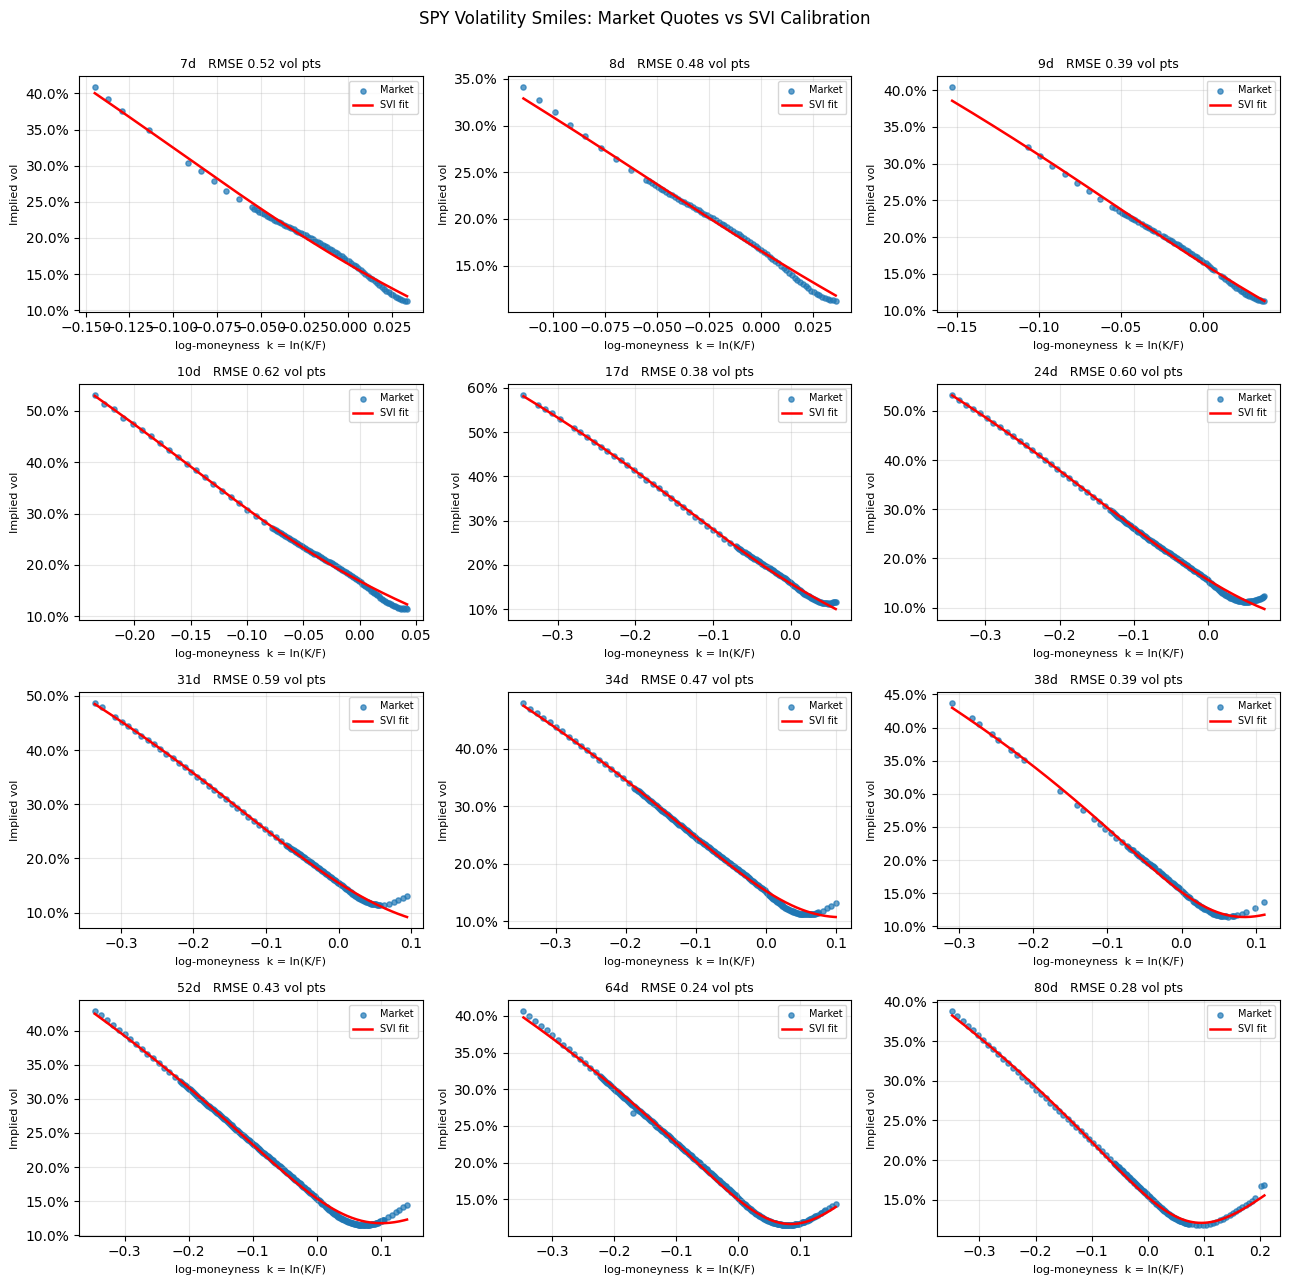

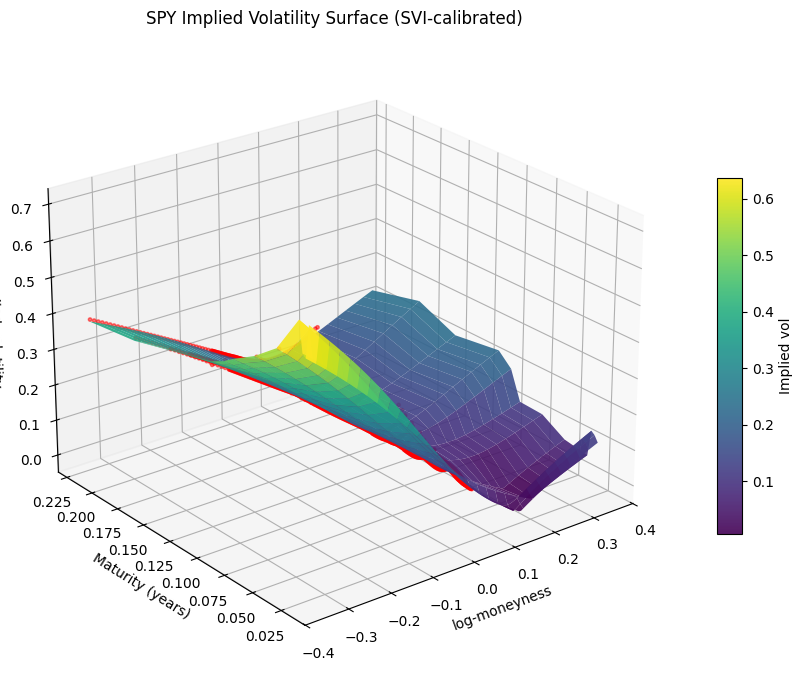

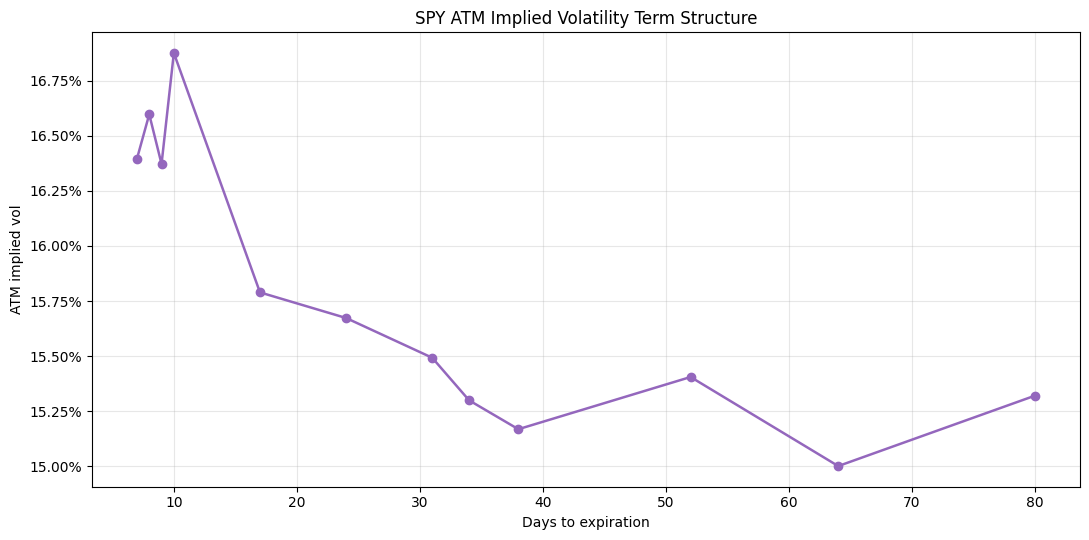

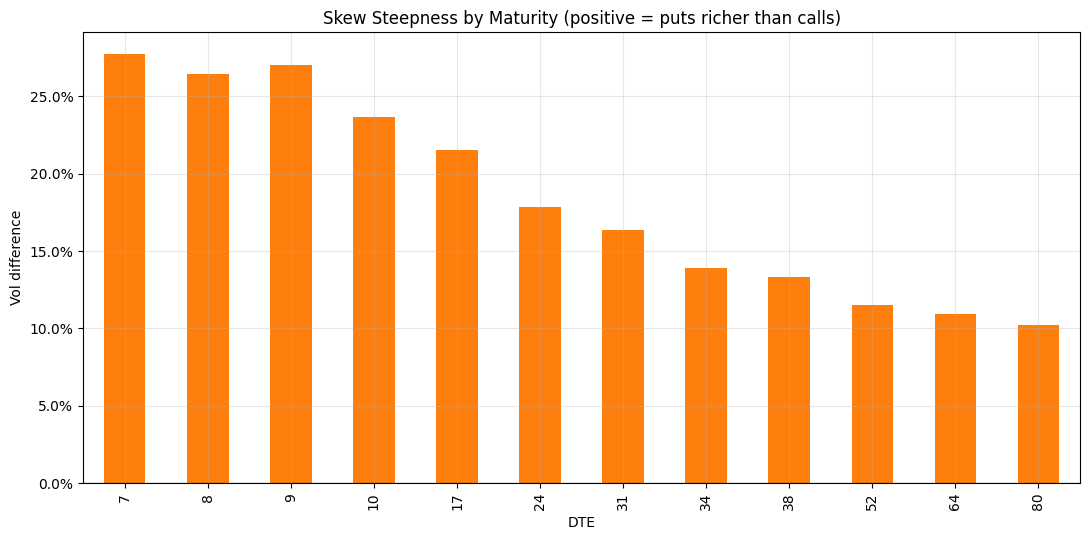

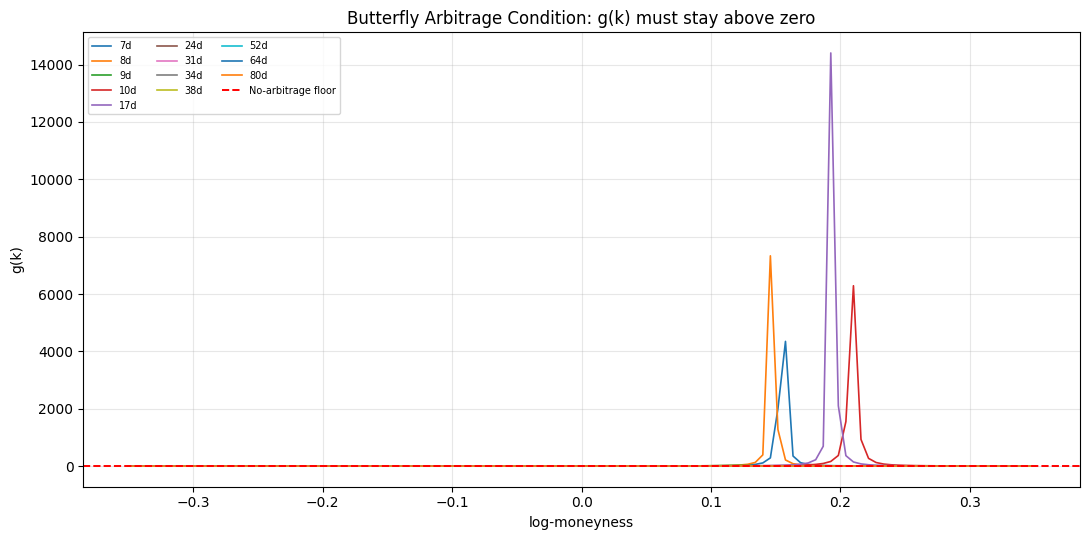

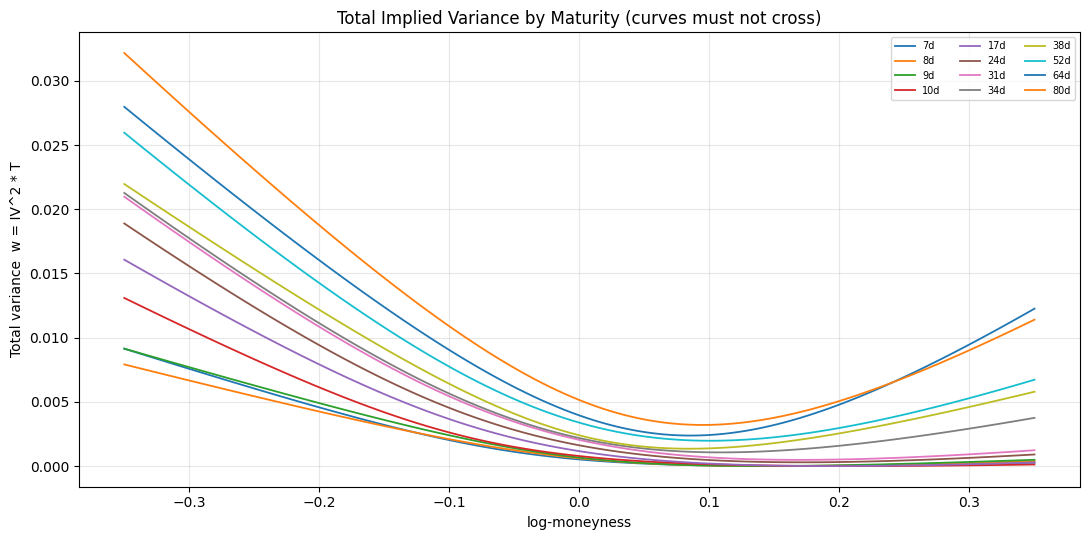

In [10]:
# ============================================================
# SECTION 10 | VISUALIZATION SUITE
# ============================================================

# --- 10.1 Per-slice smile fits -----------------------------------------
n = len(fits)
ncol = 3
nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 3.2 * nrow), squeeze=False)
for ax, (dte, f) in zip(axes.ravel(), sorted(fits.items())):
    grp = surf[surf["dte"] == dte]
    T = f["T"]
    ax.scatter(grp["k"], grp["iv"], s=14, c="tab:blue", alpha=0.7, label="Market")
    kk = np.linspace(grp["k"].min(), grp["k"].max(), 200)
    ax.plot(kk, np.sqrt(np.maximum(svi_w(kk, *f["params"]), 1e-12) / T),
            "r-", lw=1.8, label="SVI fit")
    ax.set_title(f"{dte}d   RMSE {f['rmse_vol']*100:.2f} vol pts", fontsize=9)
    ax.set_xlabel("log-moneyness  k = ln(K/F)", fontsize=8)
    ax.set_ylabel("Implied vol", fontsize=8)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
    ax.legend(fontsize=7)
for ax in axes.ravel()[n:]:
    ax.axis("off")
fig.suptitle(f"{UNDERLYING} Volatility Smiles: Market Quotes vs SVI Calibration", y=1.0)
plt.tight_layout(); plt.show()

# --- 10.2 3D fitted surface --------------------------------------------
Ts = np.array([f["T"] for _, f in sorted(fits.items())])
Kg, Tg = np.meshgrid(K_TEST, Ts)
Wg = np.zeros_like(Kg)
for i, (dte, f) in enumerate(sorted(fits.items())):
    Wg[i, :] = svi_w(K_TEST, *f["params"])
IVg = np.sqrt(np.maximum(Wg, 1e-12) / Tg[:, :])

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection="3d")
srf = ax.plot_surface(Kg, Tg, IVg, cmap=cm.viridis, alpha=0.9,
                      linewidth=0, antialiased=True, rstride=1, cstride=4)
ax.scatter(surf["k"], surf["T"], surf["iv"], c="red", s=6, alpha=0.5, label="Market quotes")
ax.set_xlabel("log-moneyness")
ax.set_ylabel("Maturity (years)")
ax.set_zlabel("Implied volatility")
ax.set_title(f"{UNDERLYING} Implied Volatility Surface (SVI-calibrated)")
ax.view_init(elev=24, azim=-128)
fig.colorbar(srf, shrink=0.55, aspect=14, label="Implied vol")
plt.tight_layout(); plt.show()

# --- 10.3 ATM term structure -------------------------------------------
atm = pd.DataFrame([
    {"DTE": d, "ATM vol": float(np.sqrt(svi_w(0.0, *f["params"]) / f["T"]))}
    for d, f in sorted(fits.items())
]).set_index("DTE")
fig, ax = plt.subplots()
atm.plot(ax=ax, marker="o", lw=1.8, legend=False, color="tab:purple")
ax.set_title(f"{UNDERLYING} ATM Implied Volatility Term Structure")
ax.set_xlabel("Days to expiration"); ax.set_ylabel("ATM implied vol")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
plt.tight_layout(); plt.show()

# --- 10.4 Skew steepness by maturity ----------------------------------
skew = []
for d, f in sorted(fits.items()):
    T = f["T"]
    lo = np.sqrt(svi_w(-0.10, *f["params"]) / T)
    hi = np.sqrt(svi_w(0.10, *f["params"]) / T)
    skew.append({"DTE": d, "25d-ish skew (10% OTM put minus call)": lo - hi})
skew_df = pd.DataFrame(skew).set_index("DTE")
fig, ax = plt.subplots()
skew_df.plot(kind="bar", ax=ax, legend=False, color="tab:orange")
ax.axhline(0, color="k", lw=0.8)
ax.set_title("Skew Steepness by Maturity (positive = puts richer than calls)")
ax.set_ylabel("Vol difference")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
plt.tight_layout(); plt.show()

# --- 10.5 Butterfly condition g(k) ------------------------------------
fig, ax = plt.subplots()
for d, f in sorted(fits.items()):
    ax.plot(K_TEST, g_function(K_TEST, f["params"]), lw=1.2, label=f"{d}d")
ax.axhline(0, color="red", ls="--", lw=1.4, label="No-arbitrage floor")
ax.set_title("Butterfly Arbitrage Condition: g(k) must stay above zero")
ax.set_xlabel("log-moneyness"); ax.set_ylabel("g(k)")
ax.legend(fontsize=7, ncol=3)
plt.tight_layout(); plt.show()

# --- 10.6 Calendar condition: total variance by maturity --------------
fig, ax = plt.subplots()
for d, f in sorted(fits.items()):
    ax.plot(K_TEST, svi_w(K_TEST, *f["params"]), lw=1.3, label=f"{d}d")
ax.set_title("Total Implied Variance by Maturity (curves must not cross)")
ax.set_xlabel("log-moneyness"); ax.set_ylabel("Total variance  w = IV^2 * T")
ax.legend(fontsize=7, ncol=3)
plt.tight_layout(); plt.show()

In [11]:
# ============================================================
# SECTION 11 | SUMMARY
# ============================================================
print("=" * 64)
print(f"{UNDERLYING} IMPLIED VOLATILITY SURFACE - SUMMARY")
print("=" * 64)
print(f"Spot: {SPOT:.2f}   Risk-free: {RF:.2%}   "
      f"Snapshot: {datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M')} UTC")
print(f"Surface points inverted: {len(surf)}")
print(f"Slices calibrated:       {len(fits)}")
print(f"Median fit error:        {fit_df['Vol RMSE'].median()*100:.2f} vol points")
print(f"Butterfly violations:    {int(bfly_df['violations'].sum())}")
print(f"Calendar violations:     {int(cal_df['violations'].sum())}")
print("\nATM term structure:")
print(atm.round(4).to_string())

SPY IMPLIED VOLATILITY SURFACE - SUMMARY
Spot: 739.09   Risk-free: 3.80%   Snapshot: 2026-07-28 00:13 UTC
Surface points inverted: 1747
Slices calibrated:       12
Median fit error:        0.45 vol points
Butterfly violations:    11
Calendar violations:     112

ATM term structure:
     ATM vol
DTE         
7     0.1640
8     0.1660
9     0.1637
10    0.1688
17    0.1579
24    0.1567
31    0.1549
34    0.1530
38    0.1517
52    0.1540
64    0.1500
80    0.1532


## Limitations
- **Snapshot only.** Free data provides a single point-in-time chain, so the
  surface cannot be tracked through time. Historical options data (Polygon,
  ORATS, CBOE DataShop) would enable surface dynamics and skew time series.
- **American exercise.** SPY options are American; this notebook prices them
  with a European (Black-76) model. For a low-dividend ETF the early-exercise
  premium is small, but it biases deep-ITM inversions, which is one reason the
  surface is built from OTM quotes only.
- **Flat rate curve.** A single short-rate proxy stands in for the full
  discount curve.

## Potential Upgrades
- **SSVI / eSSVI** for a globally arbitrage-free surface rather than
  slice-by-slice calibration
- **Local volatility** extraction via the Dupire equation from the fitted surface
- **Arbitrage repair**: project violating slices onto the nearest admissible
  SVI parameter set instead of only flagging them
- **Historical calibration** to build skew and term-structure time series
- **Monte Carlo pricing** of exotics off the calibrated surface